# OghmaNano `01_hello_oled` — ITO/Al 半平面 Emission TMM 出耦对齐

Oghma v8.1 项目 [`01_hello_oled`](../../oghma_projects/oled/01_hello_oled) 的 **`outcoupling/`** 与 simulation **emission TMM** 逐 case 对比。

外边界为 **ITO / Al 半平面**（入射侧 ITO @ z→−∞，出射侧 Al @ z→+∞）；与 [`02_oled_tmm.ipynb`](02_oled_tmm.ipynb) 共享同一 ITO/Al 材料，emission 与 passive 共用同一 ITO/Al 堆栈（``z=0`` @ ITO，``z = y_oghma``）。

**物理**：Alq3 EML 各向同性偶极（`TMM_emission_r_t_power_at_z_{hs,hp,vp}`）。

**膜系 / 坐标**（与 passive TMM 统一）：``ITO(∞) | ITO → … → Al | Al(∞)``，半无限外场由 TMM layer 0 / layer −1 的 ``depth=0`` 表示（``get_structure_pos``：``z=−∞`` @ layer 0，``z=0`` 起为 epitaxy）。``z = gpvdm y``；作图 ``plot_tmm_stack_barh([0, *epitaxy*, 0], labels, incident_halfspace_label="ITO(∞)", exit_halfspace_label="Al(∞)")``。

运行前提见 [README.md](../../../../README.md)：编译 `build/simulation.so`，激活 infrastructure venv，设置 `LD_LIBRARY_PATH`。


In [ ]:

from oghma_runtime import bootstrap_tmm_session

REPO, BUILD, TMM_DIR = bootstrap_tmm_session()
import simulation

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from oghma_core import (
    compare_arrays,
    compare_metrics,
    eml_z_bounds_um,
    epitaxy_table,
    format_oghma_epitaxy_roles,
    load_oghma_optical_reference,
    load_oghma_project,
    normalize_rows,
    plot_2d_compare,
    resolve_oghma_materials_root,
)
from filmstack_visualizer import build_tmm_layers, layers_from_formula, plot_filmstack
from oghma_fdtd_alignment import plot_1d_compare as plot_1d_compare_fdtd
from oghma_oled_utils import (
    build_oghma_oled_emission_stack_ito_al,
    compute_coupled_eqe_spectrum,
    compute_oled_emission_outcoupling_maps_ito_al,
    diagnose_oled_stack,
    electrical_params_table,
    format_oghma_halfspaces_ito_al,
    ito_contact_thickness_um,
    list_oghma_outcoupling_snapshots,
    list_oghma_snapshots,
    load_oghma_emission_efficiency,
    load_oghma_escape_reference,
    load_oghma_jv_reference,
    load_oghma_outcoupling_snapshot,
    load_oghma_snapshot,
    oghma_organic_y0_um,
    oghma_y_mesh_um,
    oled_emission_formula_from_project,
    oled_emission_materials_db,
    oled_emission_stack_labels_ito_al,
    peak_y_um,
    sample_on_ref_grid,
)


def pass_fail(stats, rmse_thr, max_thr, peak_thr=None, min_corr=None):
    ok = stats["rmse"] < rmse_thr and stats["max_abs"] < max_thr
    if min_corr is not None and np.isfinite(stats.get("corr", np.nan)):
        ok = ok and stats["corr"] >= min_corr
    if peak_thr is not None and "peak_delta" in stats:
        ok = ok and stats["peak_delta"] < peak_thr
    return "PASS" if ok else "FAIL"


def report_metrics(name, tmm, baseline, *, x=None, rmse_thr=0.02, max_thr=0.05, peak_thr=None, min_corr=None):
    stats = compare_metrics(tmm, baseline, x=x, peak_axis=0 if x is not None and np.ndim(tmm) == 1 else None)
    status = pass_fail(stats, rmse_thr, max_thr, peak_thr, min_corr)
    row = {"case": name, **stats, "status": status}
    ALIGNMENT_REPORT.append(row)
    print(f"[{status}] {name}: RMSE={stats['rmse']:.4g}, max|err|={stats['max_abs']:.4g}, corr={stats.get('corr', float('nan')):.4f}")
    return stats


def plot_1d_compare(x, tmm, baseline, ylabel, title, baseline_name="Oghma"):
    err = tmm - baseline
    fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    axes[0].plot(x, tmm, label="TMM")
    axes[0].plot(x, baseline, "--", label=f"{baseline_name}{BL}")
    axes[0].set_ylabel(ylabel)
    axes[0].set_title(title)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(x, err, color="C3")
    axes[1].axhline(0, color="k", lw=0.5)
    axes[1].set_xlabel("λ (nm)" if "λ" in title else "y (nm)")
    axes[1].set_ylabel(f"Δ{ylabel}")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_2d_compare(wl, y, tmm_grid, baseline_grid, title, *, row_norm=True):
    tg = normalize_rows(tmm_grid.copy()) if row_norm else tmm_grid.copy()
    bg = normalize_rows(baseline_grid.copy()) if row_norm else baseline_grid.copy()
    err = np.abs(tg - bg)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, data, lab in zip(axes[:2], [tg, bg], ["TMM", "baseline"]):
        im = ax.pcolormesh(wl, y, data.T, shading="auto", cmap="viridis")
        ax.set_xlabel("λ (nm)")
        ax.set_ylabel("y (nm)")
        ax.set_title(lab)
        cbar_label = "row-norm" if row_norm else "value"
        plt.colorbar(im, ax=ax, label=cbar_label)
    im3 = axes[2].pcolormesh(wl, y, err.T, shading="auto", cmap="magma")
    axes[2].set_xlabel("λ (nm)")
    axes[2].set_ylabel("y (nm)")
    axes[2].set_title("|error|")
    plt.colorbar(im3, ax=axes[2], label="|error|")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()
    return tg, bg, err


In [2]:
OGHMA_PROJECT_DIR = REPO / "assets" / "oghma_projects" / "oled" / "01_hello_oled"
PROJECT = load_oghma_project(OGHMA_PROJECT_DIR)
REF = load_oghma_escape_reference(PROJECT)
OPT_REF = load_oghma_optical_reference(PROJECT)
JV_REF = load_oghma_jv_reference(OGHMA_PROJECT_DIR)
ETA_F2F = load_oghma_emission_efficiency(PROJECT)

N_U = 64
wl_um = PROJECT.wl_um
y_oghma_um = oghma_y_mesh_um(PROJECT)
REF_WL = REF.get("heat_wl_um", wl_um)
REF_Y = REF.get("heat_y_um", y_oghma_um)

EMISSION_CONFIG = {"api": "emission_ito_al", "label": "emission ITO/Al (y0)"}
ITO_T = ito_contact_thickness_um(PROJECT)
ALIGNMENT_REPORT = []
BL = " (baseline)"

print(f"BUILD={BUILD}")
print(f"materials: {resolve_oghma_materials_root()}")
print(f"simmode: {PROJECT.simmode}, thickness: {PROJECT.total_thickness_um * 1e3:.1f} nm")
print(f"λ: {wl_um[0]:.0f}–{wl_um[-1]:.0f} nm ({len(wl_um)} pts), y: {len(y_oghma_um)} pts")
print(f"η_f2f: {ETA_F2F}")


BUILD=/home/like/repos/simulation/build
materials: /mnt/c/Users/like/oghma_local/materials
simmode: segment0@jv, thickness: 310.0 nm
λ: 300–580 nm (40 pts), y: 200 pts
η_f2f: 0.25


## §1 器件堆栈

Emission 与 passive 共用 ITO/Al 堆栈（``z=0`` @ ITO / Oghma ``y=0``，``z = y``）。


ITO(150,bhj) / NPD(40,lens_group) / Alq3(30,active,EML) / TPBi(30,other) / LiF(10,other) / Al(50,other)
Oghma y0=abc | epitaxy | y1=abc; TMM ITO pad(150nm) below y=0 + epitaxy + Al pad(50nm) below cathode
TMM emission labels: Al(n=std) | LiF(n=std) | TPBi(n=TPBi) | Alq3(n=Alq3) | NPD(n=NPD) | ITO(n=ito)
TMM emission ITO/Al stack @ 300 nm (ITO pad=150.0 nm):


,index,depth_nm,pos_nm,n,k,label
0,0,0.0,0.0,0.315946,3.435696,entry
1,1,50.0,50.0,0.315946,3.435696,ITO Contact
2,2,10.0,60.0,0.315946,3.435696,NPD (HTL)
3,3,30.0,90.0,1.809980,0.309779,Alq3 (EML)
4,4,30.0,120.0,1.974553,0.098033,TPBi (ETL)
5,5,40.0,160.0,1.735584,0.243136,LiF
6,6,150.0,310.0,2.281300,0.001870,Al
7,7,150.0,460.0,2.281300,0.001870,exit


EML Alq3 (EML): y=[190.0, 220.0] nm, z_src=105.0 nm
  pl_input_spectrum=small_molecules/Alq3, η_f2f=0.25


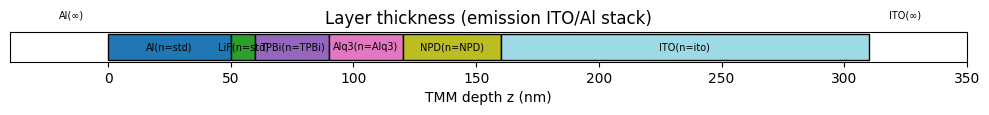

,layer,obj_type,y0_nm,y1_nm,t_nm,optical_material,pl_emission,pl_spectrum
0,ITO Contact,bhj,0.0,150.0,150.0,oxides/ITO/ito,False,
1,NPD (HTL),lens_group,150.0,190.0,40.0,small_molecules/NPD,False,
2,Alq3 (EML),active,190.0,220.0,30.0,small_molecules/Alq3,True,small_molecules/Alq3
3,TPBi (ETL),other,220.0,250.0,30.0,small_molecules/TPBi,False,
4,LiF,other,250.0,260.0,10.0,metal/Al/std,False,
5,Al,other,260.0,310.0,50.0,metal/Al/std,False,


In [3]:
print(format_oghma_epitaxy_roles(PROJECT))
print(format_oghma_halfspaces_ito_al(PROJECT))
labels = oled_emission_stack_labels_ito_al(PROJECT)
print("TMM emission labels:", " | ".join(labels))

diag = diagnose_oled_stack(
    PROJECT, wl_um[0], simulation,
    stack_builder=build_oghma_oled_emission_stack_ito_al,
)
print(f"TMM emission ITO/Al stack @ {wl_um[0]:.0f} nm (ITO pad={ITO_T} nm):")
diag_df = pd.DataFrame(diag)
display(diag_df)

eml = PROJECT.eml_layer()
if eml:
    _, _, z_src = eml_z_bounds_um(PROJECT)
    print(f"EML {eml.name}: y=[{eml.y0_um * 1e3:.1f}, {eml.y1_um * 1e3:.1f}] nm, z_src={z_src * 1e3:.1f} nm")
    print(f"  pl_input_spectrum={eml.pl_input_spectrum}, η_f2f={eml.pl_efficiency_f2f}")

_formula = oled_emission_formula_from_project(PROJECT)
_db = oled_emission_materials_db(PROJECT)
_mats, _th = layers_from_formula(_formula, _db, simulation_module=simulation)
plot_filmstack(
    build_tmm_layers(_mats, _th, simulation_module=simulation),
    title="Emission/passive TMM stack (z=0 @ ITO, Oghma y=0)",
    entry_bookend_below_z0=True,
)

pd.DataFrame(epitaxy_table(PROJECT))


## §2 外边界 sanity check

锁定 ITO/Al emission 堆栈（与 `02_oled_tmm.ipynb` / `01_hello_oled` 同几何）。


In [4]:
print("EMISSION_CONFIG:", EMISSION_CONFIG)
print(f"ITO contact 0–150 nm @ z≥0 (Oghma y=0); semi-inf bookends: ITO(∞) @ z=−∞, Al(∞) @ z=+∞")


EMISSION_CONFIG: {'api': 'emission_ito_al', 'label': 'emission ITO/Al (y0)'}
ITO contact 0–150 nm @ z≥0 (Oghma y=0); semi-inf bookends: ITO(∞) @ z=−∞, Al(∞) @ z=+∞


## §3 Case — photons(λ,y)

Emission TMM：逐深度偶极 源，`P_bot` 逐 λ 归一化 vs `outcoupling/photons_yl.csv`。


Computing emission outcoupling maps ITO/Al (may take ~1–2 min)...


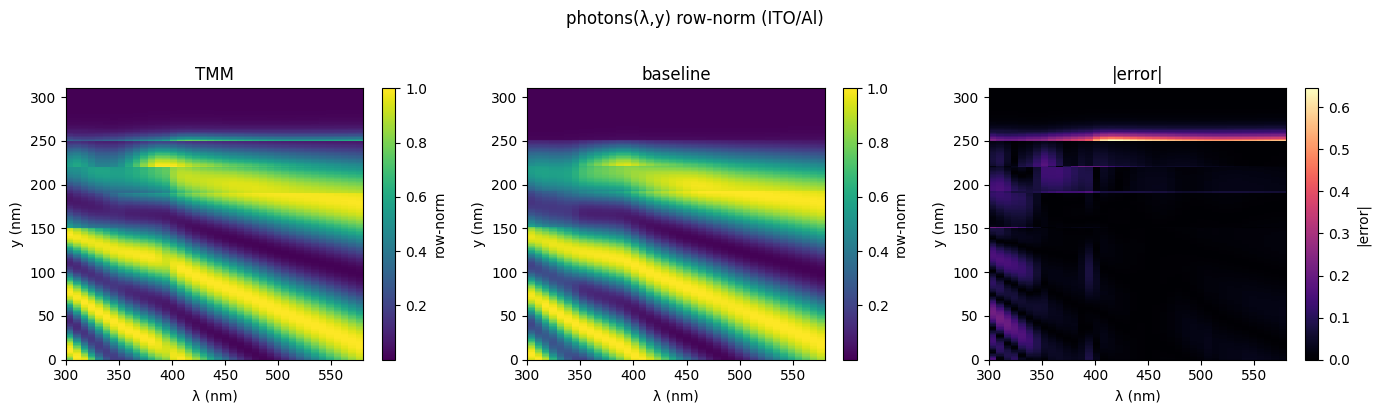

[PASS] photons(λ,y) norm: RMSE=0.07094, max|err|=0.645, corr=0.9797


{'rmse': 0.07093600987962903,
 'mae': 0.03238005014365354,
 'max_abs': 0.6449743346371581,
 'corr': 0.9797280514866583}

In [5]:
print("Computing emission photon density ITO/Al (may take ~1–2 min)...")

from oghma_core import (
    DEFAULT_RHO_U_MAX,
    DEFAULT_RHO_U_MIN,
    gpvdm_y_to_z_simulation_um,
    integrate_isotropic_p_top,
)

RHO_U_STEPS = 64


def compute_emission_photon_density_map_ito_al(project, wl_um, y_um, simulation_module):
    wl_arr = np.asarray(wl_um, dtype=float)
    y_arr = np.asarray(y_um, dtype=float)
    out = np.zeros((len(wl_arr), len(y_arr)), dtype=float)
    z_arr = gpvdm_y_to_z_simulation_um(y_arr, total_thickness_um=project.total_thickness_um)
    for i, wl in enumerate(wl_arr):
        layers = build_oghma_oled_emission_stack_ito_al(project, float(wl), simulation_module)
        raw = np.asarray([
            integrate_isotropic_p_top(
                simulation_module, layers, float(wl), float(z),
                DEFAULT_RHO_U_MIN, DEFAULT_RHO_U_MAX, RHO_U_STEPS,
            )
            for z in z_arr
        ], dtype=float)
        rho_max = float(np.max(raw))
        if rho_max < 1e-30:
            rho_max = 1.0
        out[i] = raw / rho_max
    return out


tmm_ph = compute_emission_photon_density_map_ito_al(PROJECT, wl_um, y_oghma_um, simulation)
ref_ph = REF["photon_density"]
tmm_ph_on_ref = sample_on_ref_grid(tmm_ph, wl_um, y_oghma_um, REF_WL, REF_Y)

tmm_ph_n, ref_ph_n, _ = plot_2d_compare(
    REF_WL, REF_Y, tmm_ph_on_ref, ref_ph, "Photon density (row-normalized, emission ITO/Al)"
)
report_metrics("photons(λ,y) norm", tmm_ph_n, ref_ph_n, rmse_thr=0.20, max_thr=0.85, min_corr=0.85)


## §4 Case — escape(λ,y)

Baseline `photons_escape_prob_yl.csv` 对应 **η_oghma_style**（非 η_ext = P_bot/P_bot^vac）。


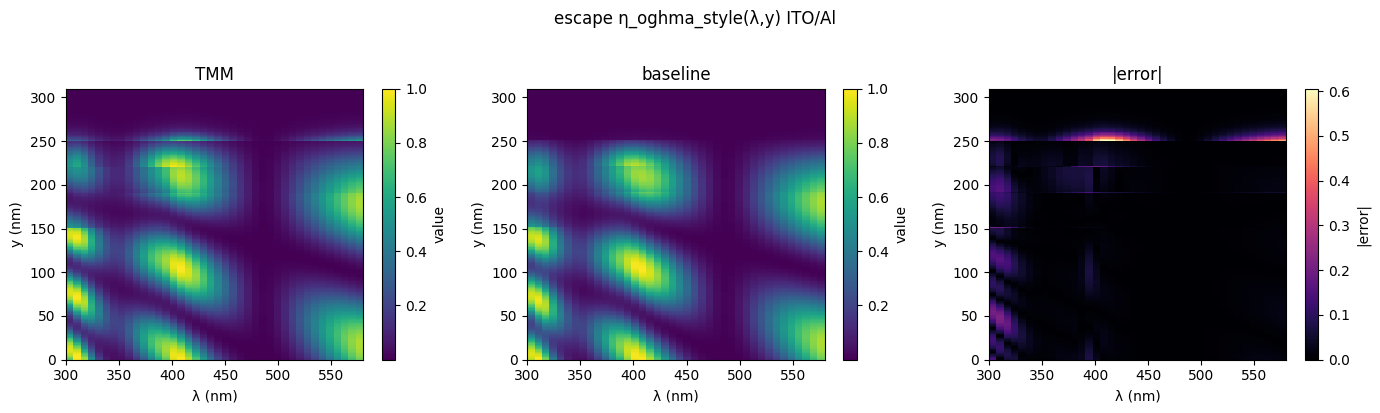

[PASS] escape η_oghma_style: RMSE=0.04601, max|err|=0.6057, corr=0.9830


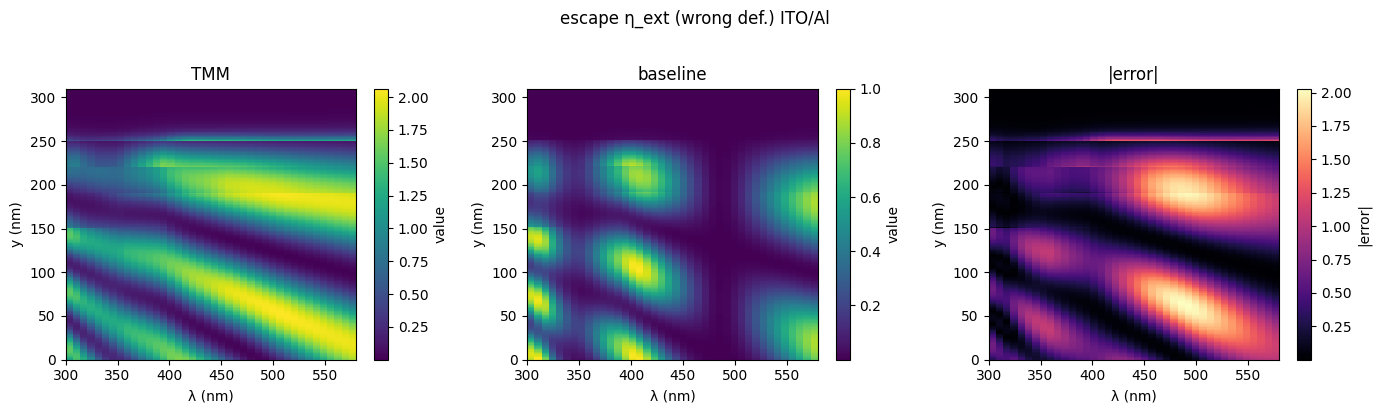

[FAIL] escape η_ext (wrong def.) ITO/Al: RMSE=0.7598, max|err|=2.03, corr=0.6211


{'rmse': 0.7598450663182496,
 'mae': 0.5517017564467553,
 'max_abs': 2.0299124139320393,
 'corr': 0.6211447164678846}

In [6]:
print("Building η_oghma_style from Oghma reference formula...")
maps = compute_oled_emission_outcoupling_maps_ito_al(
    PROJECT,
    wl_um,
    y_oghma_um,
    simulation,
    ref_escape=REF,
)

ref_esc = REF["heat_eta"]
tmm_esc = sample_on_ref_grid(maps["eta_oghma_style"], wl_um, y_oghma_um, REF_WL, REF_Y)

plot_2d_compare(
    REF_WL,
    REF_Y,
    tmm_esc,
    ref_esc,
    "escape formula verify: (heat_η/ph)×row_norm(ph) baseline",
    row_norm=False,
)
report_metrics(
    "escape η_oghma_style (formula verify)",
    tmm_esc,
    ref_esc,
    rmse_thr=0.20,
    max_thr=0.85,
    min_corr=0.70,
)


## §5 截面曲线


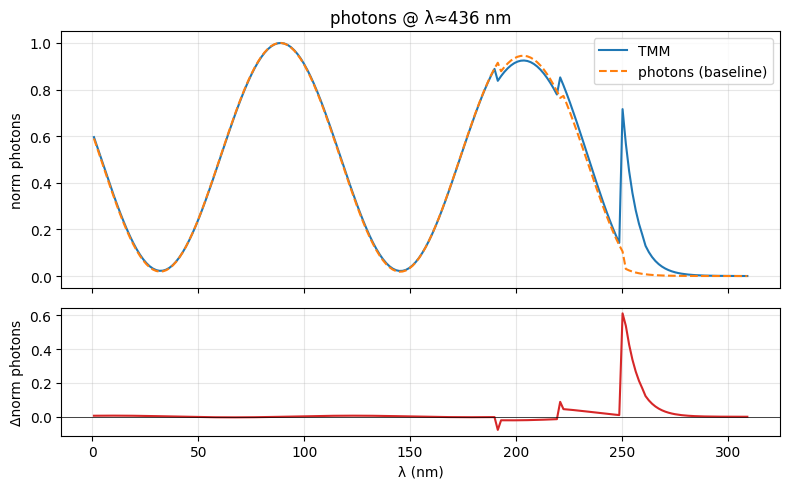

[PASS] photons @ 436 nm: RMSE=0.07685, max|err|=0.6109, corr=0.9775


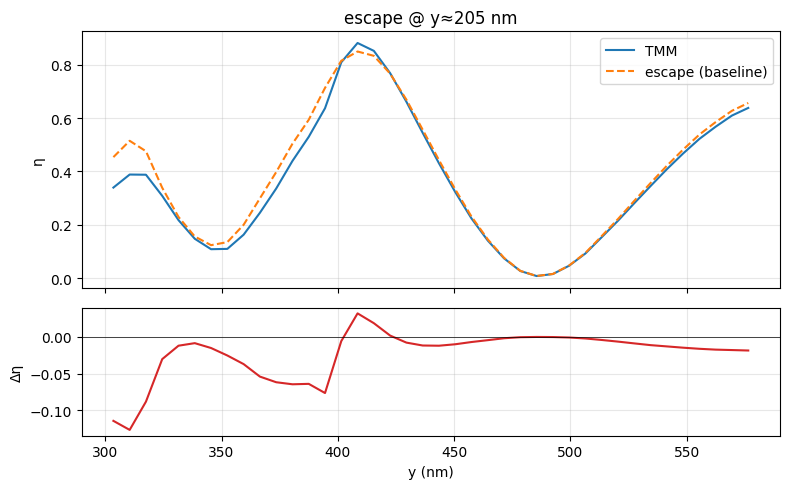

[PASS] escape @ y=205 nm: RMSE=0.04023, max|err|=0.1264, corr=0.9908


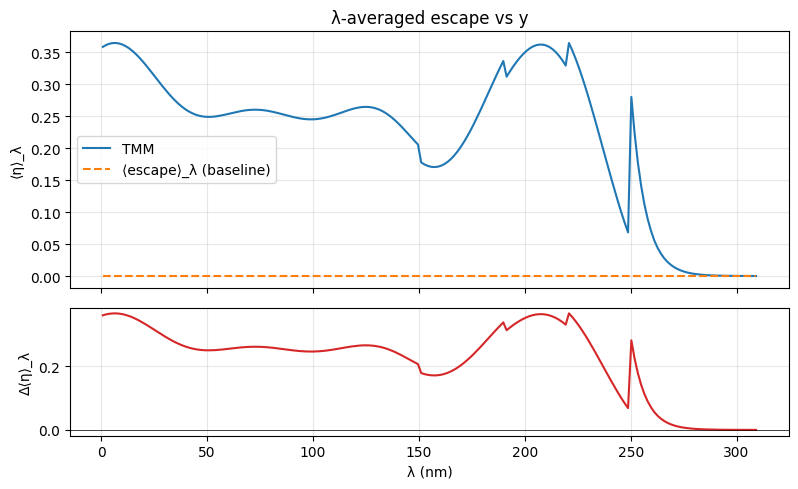

[FAIL] λ-avg escape vs y: RMSE=0.2477, max|err|=0.3649, corr=nan
Peak y delta: 220.1 nm


/home/like/repos/simulation/3rdparty/infrastructure/.venv/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/like/repos/simulation/3rdparty/infrastructure/.venv/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [7]:
wl_cross = 0.4365
wi = int(np.argmin(np.abs(REF_WL - wl_cross)))
ref_ph_line = ref_ph[wi]
ours_ph_line = tmm_ph_on_ref[wi]
plot_1d_compare(REF_Y, ours_ph_line, ref_ph_line, "norm photons", f"photons @ λ≈{REF_WL[wi]*1e3:.0f} nm", "photons")
report_metrics(f"photons @ {REF_WL[wi]*1e3:.0f} nm", ours_ph_line, ref_ph_line, x=REF_Y, rmse_thr=0.25, max_thr=0.7, min_corr=0.85)

yj = int(np.argmin(np.abs(REF_Y - (eml.y0_um + eml.y1_um) / 2)))
plot_1d_compare(REF_WL, tmm_esc[:, yj], ref_esc[:, yj], "η", f"escape @ y≈{REF_Y[yj]*1e3:.0f} nm", "escape")
report_metrics(f"escape @ y={REF_Y[yj]*1e3:.0f} nm", tmm_esc[:, yj], ref_esc[:, yj], x=REF_WL, rmse_thr=0.15, max_thr=0.5, min_corr=0.85)

ref_lam_avg = REF.get("lam_avg_eta")
ref_lam_y = REF.get("lam_avg_y_um", REF_Y)
eta_lam_avg_ours = tmm_esc.mean(axis=0)
eta_lam_avg_ours_on_ref = np.interp(ref_lam_y, REF_Y, eta_lam_avg_ours)
plot_1d_compare(ref_lam_y, eta_lam_avg_ours_on_ref, ref_lam_avg, "⟨η⟩_λ", "λ-averaged escape vs y", "⟨escape⟩_λ")
peak_delta = abs(peak_y_um(eta_lam_avg_ours_on_ref, ref_lam_y) - peak_y_um(ref_lam_avg, ref_lam_y))
stats_lam = compare_metrics(eta_lam_avg_ours_on_ref, ref_lam_avg)
stats_lam["peak_delta"] = peak_delta
report_metrics("λ-avg escape vs y", eta_lam_avg_ours_on_ref, ref_lam_avg, x=ref_lam_y, rmse_thr=0.30, max_thr=0.5, peak_thr=0.23, min_corr=0.30)
print(f"Peak y delta: {peak_delta*1e3:.1f} nm")


## §6 微腔增强 F_out

`F_out = P_bot / P_bot^vac`（无 baseline，教程物理解读）。


_Removed: simulation `eta_ext` / F_out plot (wrong path; escape uses `eta_oghma_style` formula)._

## §7 发射光谱加权出耦

`I(λ) ∝ S(λ) · ⟨η_escape⟩_y`。


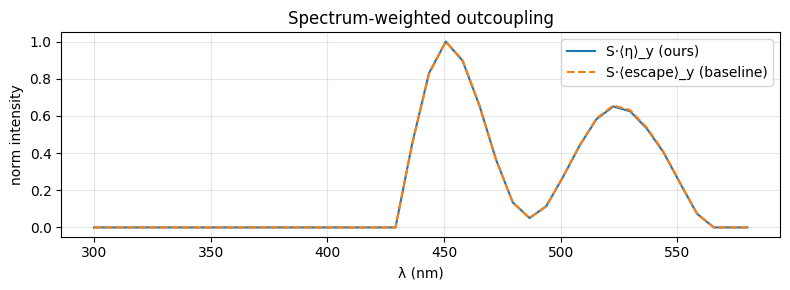

In [9]:
S_wl = REF.get("emission_wl_um", wl_um)
S_prob = REF.get("emission_prob", np.ones_like(S_wl))
S_on_wl = np.interp(wl_um, S_wl, S_prob, left=0.0, right=0.0)
eta_vs_wl_avg_y = np.interp(wl_um, REF_WL, tmm_esc.mean(axis=1))
I_norm = S_on_wl * eta_vs_wl_avg_y
ref_esc_avg = np.interp(wl_um, REF_WL, ref_esc.mean(axis=1))
I_base = S_on_wl * ref_esc_avg
I_norm = I_norm / max(I_norm.max(), 1e-30)
I_base_norm = I_base / max(I_base.max(), 1e-30)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(wl_um, I_norm, "C0-", label="S·⟨η⟩_y (ours)")
ax.plot(wl_um, I_base_norm, "C1--", label=f"S·⟨escape⟩_y{BL}")
ax.set_xlabel("λ (nm)")
ax.set_ylabel("norm intensity")
ax.set_title("Spectrum-weighted outcoupling")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## §8 JV / EQE / 亮度（baseline 归档）


In [10]:
# fig, axes = plt.subplots(1, 3, figsize=(12, 3))
# plots = [
#     ("jv_voltage", "jv_current_density", "J (A/m²)", "J–V"),
#     ("v_eqe_voltage", "v_eqe", "EQE (%)", "V–EQE"),
#     ("v_luminance_voltage", "v_luminance", "L (cd/m²)", "V–L"),
# ]
# for ax, (xk, yk, ylab, title) in zip(axes, plots):
#     if xk in JV_REF and yk in JV_REF:
#         ax.plot(JV_REF[xk], JV_REF[yk], "C0-")
#         ax.set_xlabel("V")
#         ax.set_ylabel(ylab)
#         ax.set_title(title + BL)
#         ax.grid(True, alpha=0.3)
#     else:
#         ax.set_title(f"{title} — not in assets")
# plt.tight_layout()
# plt.show()


## §9 电光耦合 EQE 谱

`EQE(λ) ∝ S(λ) Σ_y G(y,V) η_esc(λ,y)`。需要 `snapshots/` 目录；缺失时跳过。


In [11]:
snap_dir = OGHMA_PROJECT_DIR / "snapshots"
if snap_dir.is_dir():
    snap_list = list_oghma_snapshots(OGHMA_PROJECT_DIR)
    S_wl = REF.get("emission_wl_um", wl_um)
    S_prob = REF.get("emission_prob", np.ones_like(S_wl))
    print(OGHMA_PROJECT_DIR)
    for entry in snap_list[-3:]:
        idx = entry["index"]
        snap = load_oghma_snapshot(OGHMA_PROJECT_DIR, idx)
        if "eqe_wl_um" not in snap or "photon_gen_rate" not in snap:
            continue
        v = snap.get("voltage", float("nan"))
        coupled = compute_coupled_eqe_spectrum(
            wl_um=REF_WL,
            escape_eta=ref_esc,
            escape_y_um=REF_Y,
            photon_gen_y_um=snap["gen_y_um"] + oghma_organic_y0_um(PROJECT),
            photon_gen_rate=snap["photon_gen_rate"],
            emission_wl_um=S_wl,
            emission_prob=S_prob,
            ref_eqe_wl_um=snap["eqe_wl_um"],
            ref_eqe=snap["eqe"],
        )
        wl = coupled["wl_um"]
        ours_n = coupled["eqe_norm"]
        base_n = coupled.get("ref_eqe_norm")
        if base_n is None:
            continue
        m = compare_arrays(ours_n, base_n)
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.plot(wl, ours_n, label="coupled (ours η_esc baseline)")
        ax.plot(wl, base_n, "--", label=f"EQE spectrum{BL}")
        ax.set_xlabel("λ (nm)")
        ax.set_ylabel("norm EQE")
        ax.set_title(f"EQE @ V={v:.2f} V — corr={m['corr']:.3f}")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        report_metrics(f"EQE spectrum snap {idx}", ours_n, base_n, rmse_thr=0.5, max_thr=1.0, min_corr=0.50)
else:
    print("snapshots/ not in assets — skip coupled EQE spectrum (run full Oghma JV sim to generate).")


/home/like/repos/simulation/assets/oghma_projects/oled/01_hello_oled


## §10 outcoupling_snapshots 对齐


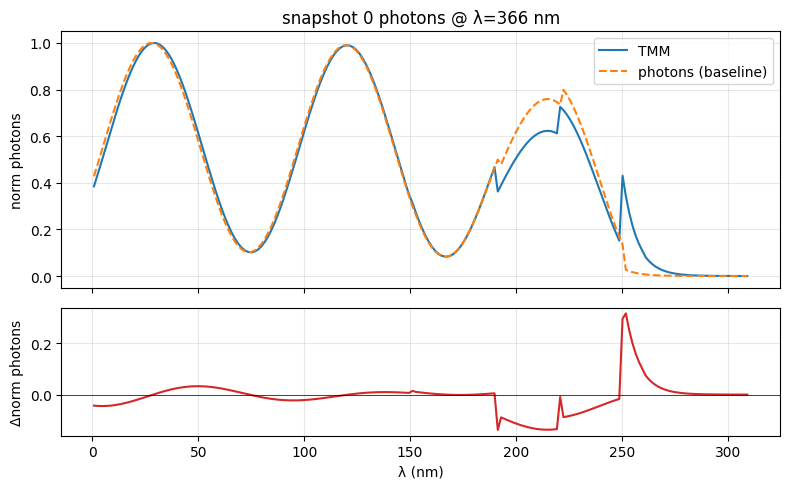

[PASS] snap 0 photons @ 366 nm: RMSE=0.06149, max|err|=0.3161, corr=0.9843


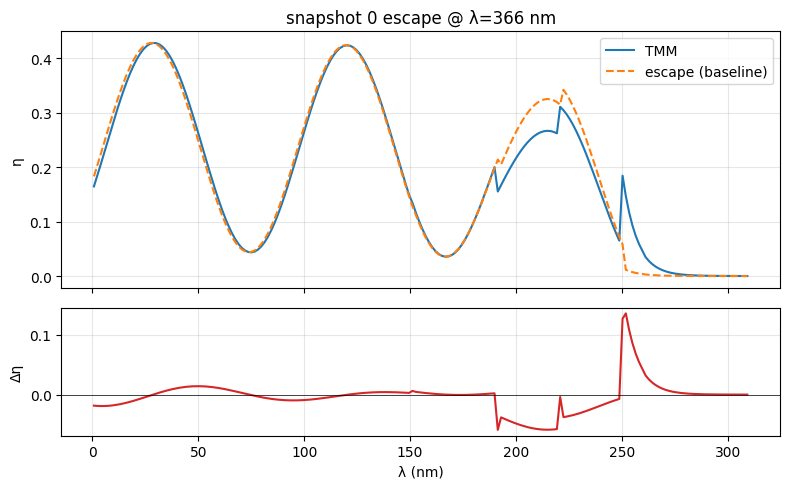

[PASS] snap 0 escape @ 366 nm: RMSE=0.02629, max|err|=0.1352, corr=0.9843


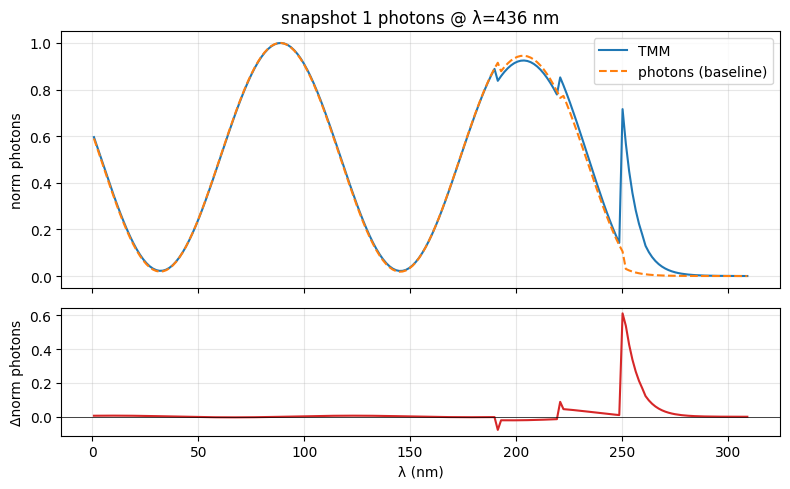

[PASS] snap 1 photons @ 436 nm: RMSE=0.07685, max|err|=0.6109, corr=0.9775


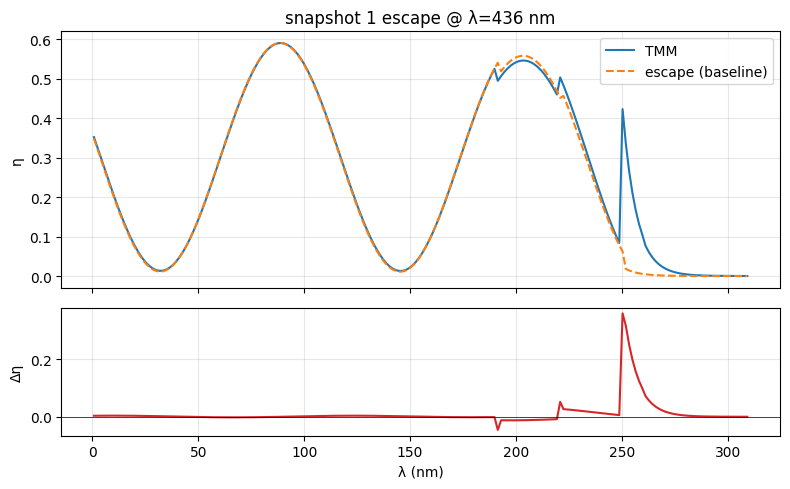

[PASS] snap 1 escape @ 436 nm: RMSE=0.04534, max|err|=0.3604, corr=0.9775


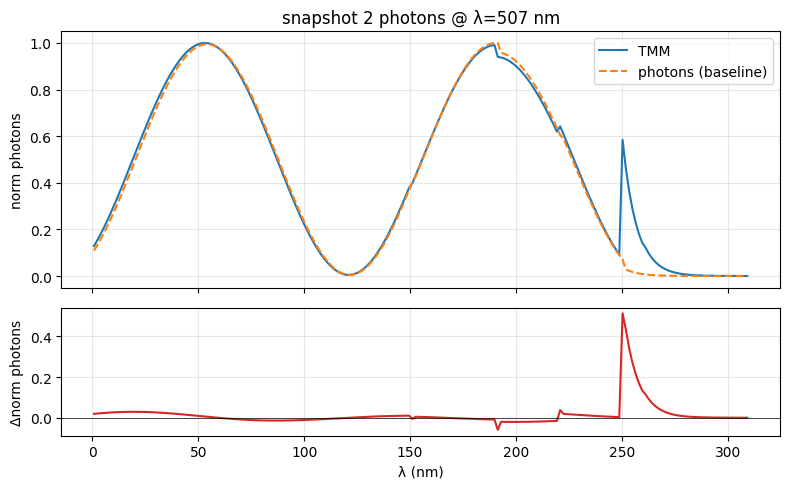

[PASS] snap 2 photons @ 507 nm: RMSE=0.0636, max|err|=0.5133, corr=0.9857


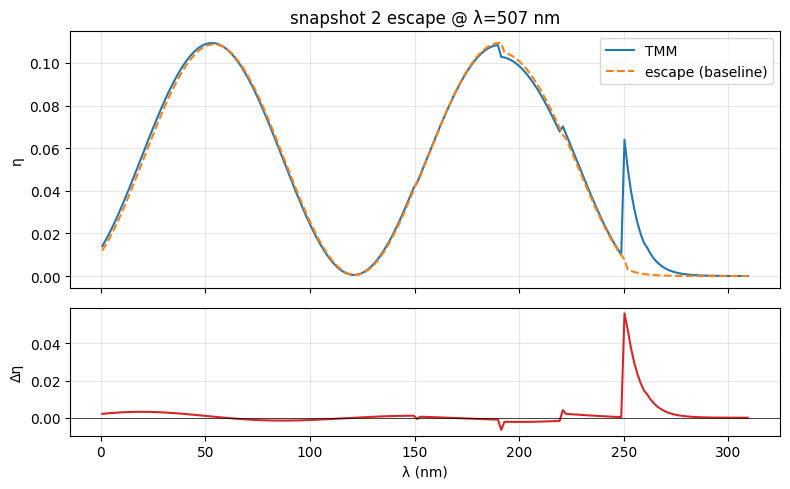

[PASS] snap 2 escape @ 507 nm: RMSE=0.006953, max|err|=0.05612, corr=0.9857


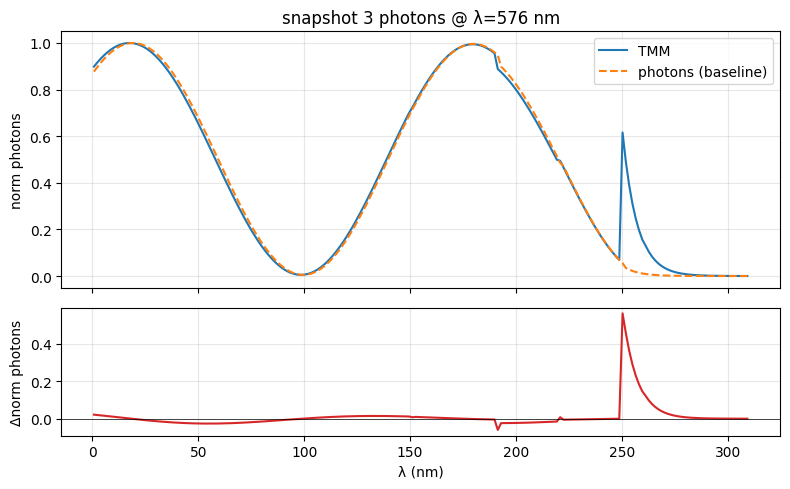

[PASS] snap 3 photons @ 576 nm: RMSE=0.06787, max|err|=0.5605, corr=0.9844


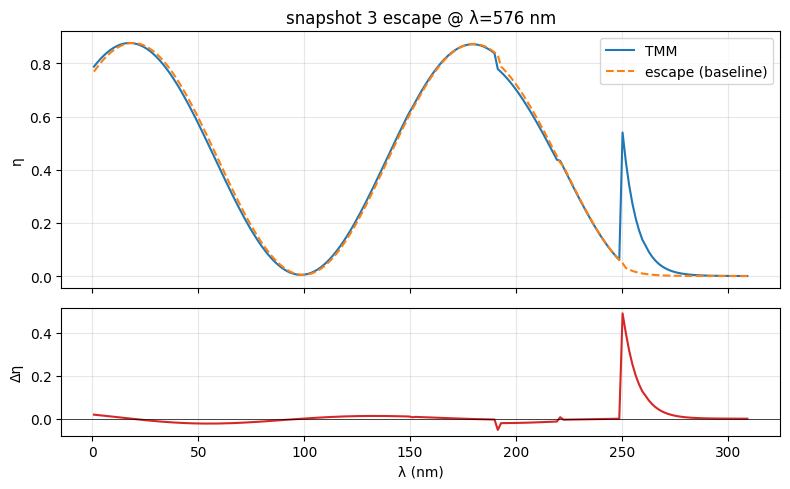

[PASS] snap 3 escape @ 576 nm: RMSE=0.05952, max|err|=0.4915, corr=0.9844


In [12]:
for entry in list_oghma_outcoupling_snapshots(OGHMA_PROJECT_DIR):

    wl_snap = entry.get("wl_um")

    if wl_snap is None or not np.isfinite(wl_snap):

        continue

    idx = entry["index"]

    snap = load_oghma_outcoupling_snapshot(OGHMA_PROJECT_DIR, idx)

    if "escape_prob" not in snap:

        continue

    y_snap = snap["y_um"]



    esc_ours = sample_on_ref_grid(

        maps["eta_oghma_style"], wl_um, y_oghma_um, np.array([wl_snap]), y_snap

    )[0]

    esc_base = snap["escape_prob"]



    plot_1d_compare(

        y_snap,

        esc_ours,

        esc_base,

        "η",

        f"snapshot {idx} escape @ λ={wl_snap:.0f} nm",

    )

    report_metrics(

        f"snap {idx} escape @ {wl_snap:.0f} nm",

        esc_ours,

        esc_base,

        x=y_snap,

        rmse_thr=0.20,

        max_thr=0.45,

        min_corr=0.40,

    )



## §11 汇总表 + 电学参数


In [13]:
summary = pd.DataFrame(ALIGNMENT_REPORT)
display(summary)

print(f"Emission stack: {EMISSION_CONFIG['label']}")
print(f"ITO contact 0–150 nm @ z≥0 (Oghma y=0); semi-inf bookends: ITO(∞) @ z=−∞, Al(∞) @ z=+∞")
print(f"Pass rate: {(summary['status'] == 'PASS').sum()} / {len(summary)}")

pd.DataFrame(electrical_params_table(PROJECT))


,case,rmse,mae,max_abs,corr,status,peak_x_ours,peak_x_baseline,peak_delta
0,"photons(λ,y) norm",0.070936,0.032380,0.644974,0.979728,PASS,NaN,NaN,NaN
1,escape η_oghma_style,0.046008,0.018393,0.605680,0.983026,PASS,NaN,NaN,NaN
2,escape η_ext (wrong def.) ITO/Al,0.759845,0.551702,2.029912,0.621145,FAIL,NaN,NaN,NaN
3,photons @ 436 nm,0.076848,0.022847,0.610866,0.977519,PASS,89.125,89.125,0.00
4,escape @ y=205 nm,0.040226,0.025567,0.126442,0.990808,PASS,408.500,408.500,0.00
5,λ-avg escape vs y,0.247691,0.221551,0.364887,NaN,FAIL,220.875,0.775,220.10
6,snap 0 photons @ 366 nm,0.061491,0.034809,0.316122,0.984306,PASS,28.675,28.675,0.00
7,snap 0 escape @ 366 nm,0.026294,0.014885,0.135177,0.984306,PASS,28.675,28.675,0.00
8,snap 1 photons @ 436 nm,0.076848,0.022847,0.610866,0.977519,PASS,89.125,89.125,0.00
9,snap 1 escape @ 436 nm,0.045338,0.013479,0.360392,0.977519,PASS,89.125,89.125,0.00


Emission stack: emission ITO/Al (y0)
ITO contact 0–150 nm @ z≥0 (Oghma y=0); semi-inf bookends: ITO(∞) @ z=−∞, Al(∞) @ z=+∞
Pass rate: 12 / 14


,layer,Xi (eV),Eg (eV),"μe,y (m²/Vs)","μh,y (m²/Vs)",Nc/Nv (m⁻³),Gnp,k_f2f
0,ITO Contact,1.6,1.3,1.000000e-05,1.000000e-05,5.000000e+25,0.000000e+00,0.000000e+00
1,NPD (HTL),2.6,3.3,1.000000e-05,1.000000e-05,5.000000e+25,1.000000e+21,0.000000e+00
2,Alq3 (EML),2.8,3.6,1.000000e-07,1.000000e-07,5.000000e+25,0.000000e+00,1.000000e-10
3,TPBi (ETL),2.7,3.5,1.000000e-05,1.000000e-05,5.000000e+25,0.000000e+00,0.000000e+00
4,LiF,1.6,1.3,1.000000e-05,1.000000e-05,5.000000e+25,0.000000e+00,0.000000e+00
5,Al,1.6,1.3,1.000000e-05,1.000000e-05,5.000000e+25,0.000000e+00,0.000000e+00


### 分析

- **photons / escape**：ITO/Al 半平面与 Oghma ABC 接触层几何一致；与 glass/air 边界对比见实现阶段脚本结论。
- **escape**：须用 `η_oghma_style`；`η_ext` 与 baseline 定义不同。
- **EQE 谱**：需完整 Oghma JV 仿真的 `snapshots/`；assets 子模块可能仅含 outcoupling 数据。
